# Assignment 1: Understanding Generative and Discriminative Models Using MNIST

**Objective:** Understand the difference between a discriminative model and a generative model using the MNIST dataset (digits 0 and 1 only).

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

## Step 2: Dataset Preparation

Load MNIST and keep only the images representing digits 0 and 1.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 12665
Testing  samples : 2115


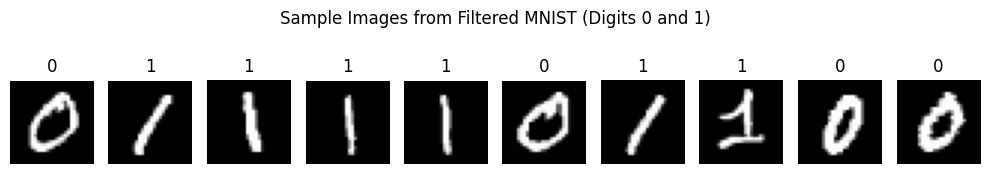

In [2]:
# Load MNIST
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Filter to keep only 0s and 1s
train_mask = (y_train_full == 0) | (y_train_full == 1)
test_mask  = (y_test_full  == 0) | (y_test_full  == 1)

X_train = X_train_full[train_mask]
y_train = y_train_full[train_mask]
X_test  = X_test_full[test_mask]
y_test  = y_test_full[test_mask]

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# Normalize pixel values to [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

# Visualize a few samples
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample Images from Filtered MNIST (Digits 0 and 1)')
plt.tight_layout()
plt.show()

## Step 3: Discriminative Model — Logistic Regression

A discriminative model learns to classify inputs by finding a decision boundary between classes.
Here, we use Logistic Regression to classify whether a given image is digit 0 or digit 1.

In [3]:
# Flatten images: (28, 28) → (784,)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0],  -1)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_flat, y_train)

# Evaluate
y_pred = lr_model.predict(X_test_flat)
accuracy = accuracy_score(y_test, y_pred)
print(f"Discriminative Model (Logistic Regression) Accuracy: {accuracy * 100:.2f}%")

Discriminative Model (Logistic Regression) Accuracy: 99.95%


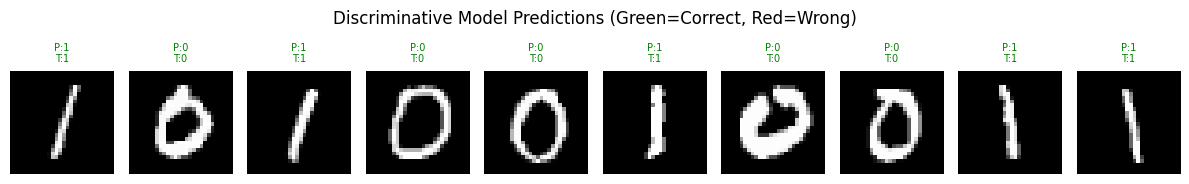

In [4]:
# Visualize some predictions
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_test[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"P:{y_pred[i]}\nT:{y_test[i]}", fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Discriminative Model Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

## Step 4: Generative Model - Autoencoder

A generative model learns the underlying data distribution, not just the boundary between classes.
We use a simple Autoencoder, it compresses images into a latent representation and then reconstructs them.

Architecture:
- **Encoder:** 784 → Dense(128) → Dense(32) *(latent space)*
- **Decoder:** Dense(128) → Dense(784) *(reconstruction)*

In [5]:
# Flatten for Dense autoencoder
X_train_ae = X_train_norm.reshape(-1, 784)
X_test_ae  = X_test_norm.reshape(-1, 784)

# Build Autoencoder
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
encoded = Dense(32, activation='relu')(x)

# Decoder
x = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    batch_size=128,
    validation_data=(X_test_ae, X_test_ae),
    verbose=1
)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2561 - val_loss: 0.1397
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1298 - val_loss: 0.1180
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1116 - val_loss: 0.1035
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0999 - val_loss: 0.0938
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0919 - val_loss: 0.0879
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0873 - val_loss: 0.0842
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0839 - val_loss: 0.0814
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0815 - val_loss: 0.0796
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0794 - val_loss: 0.0775
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0777 - val_loss: 0.0760
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0763 - val_loss: 0.0747
Epoch 12/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0750 - va

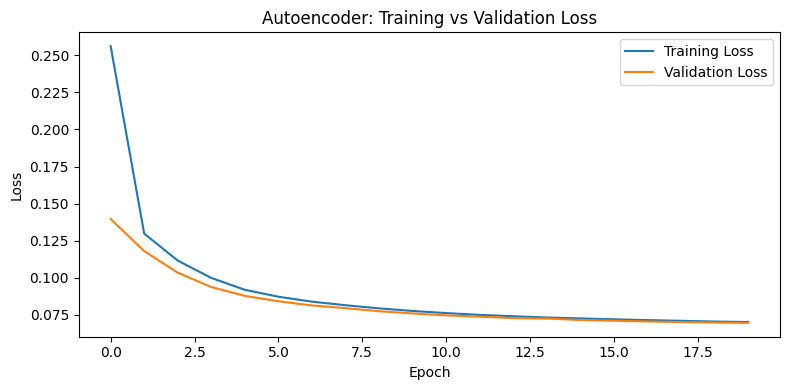

In [7]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder: Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Step 5: Examples of Generated Digit Images

The autoencoder reconstructs images from its learned latent representation, these are the "generated" examples.

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


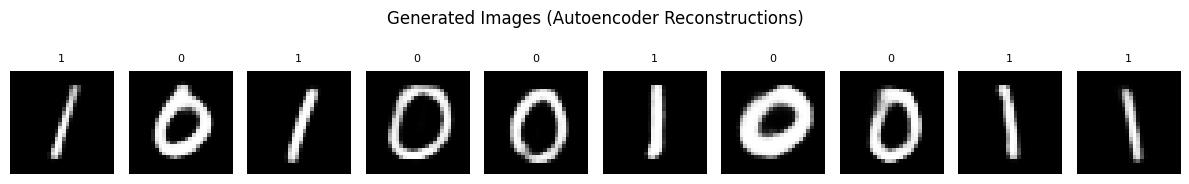

In [8]:
# Generate reconstructed images
reconstructed = autoencoder.predict(X_test_ae)
reconstructed_imgs = reconstructed.reshape(-1, 28, 28)

# Show generated examples
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(reconstructed_imgs[i], cmap='gray')
    plt.title(str(y_test[i]), fontsize=8)
    plt.axis('off')
plt.suptitle('Generated Images (Autoencoder Reconstructions)')
plt.tight_layout()
plt.show()

## Step 6: Visual Comparison - Real Images | Predictions | Generated Images

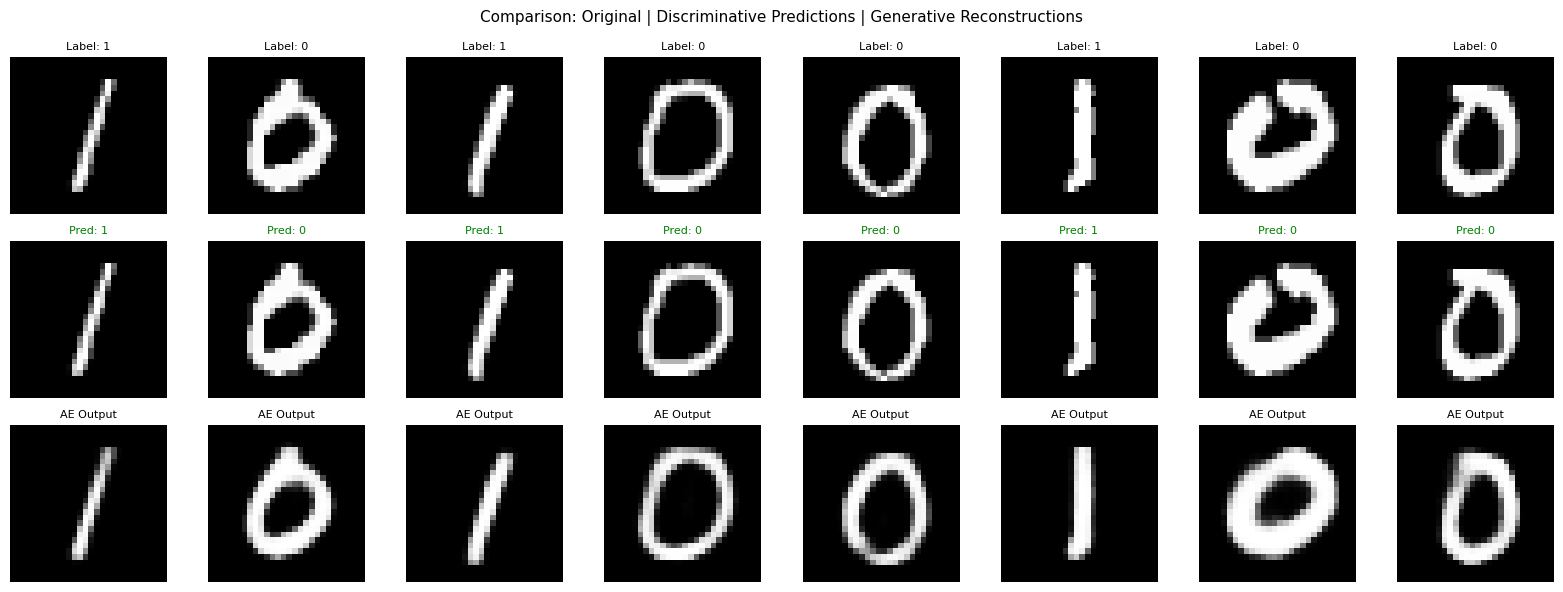

In [9]:
n = 8

plt.figure(figsize=(16, 6))

for i in range(n):
    # Row 1: Original Images
    plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    if i == 0:
        plt.ylabel('Original\nImages', fontsize=9)
    plt.title(f"Label: {y_test[i]}", fontsize=8)
    plt.axis('off')

    # Row 2: Discriminative Model Predictions
    plt.subplot(3, n, i + n + 1)
    plt.imshow(X_test[i], cmap='gray')
    if i == 0:
        plt.ylabel('Discriminative\nPrediction', fontsize=9)
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"Pred: {y_pred[i]}", fontsize=8, color=color)
    plt.axis('off')

    # Row 3: Autoencoder Generated Images
    plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(reconstructed_imgs[i], cmap='gray')
    if i == 0:
        plt.ylabel('Generated\n(Autoencoder)', fontsize=9)
    plt.title('AE Output', fontsize=8)
    plt.axis('off')

plt.suptitle('Comparison: Original | Discriminative Predictions | Generative Reconstructions', fontsize=11)
plt.tight_layout()
plt.show()

## Written Reflection

### What did the discriminative model learn?

The Logistic Regression model learned a decision boundary that separates the two classes - digit 0 and digit 1. It looks at the pixel values of an image and figures out which side of that boundary it falls on. It does not really "understand" what a digit looks like; it just learns what combination of pixels is more likely to be a 0 versus a 1. Since the two digits are visually quite different, the model achieves very high accuracy on this task.

### What did the generative model learn?

The autoencoder learned the internal structure and patterns of the digit images. Through training, the encoder compressed each image into a small 32-dimensional representation (the latent space), and the decoder learned to reconstruct the original image from that compressed form. This means the model had to understand what the digits actually look like the curves of a 0, the strokes of a 1, well enough to recreate them from scratch. The reconstructed outputs are generated versions of the digits.

### How are the two approaches different?

The core difference lies in what each model learns. A discriminative model learns P(Y|X) - the probability of a label given the input. It only cares about separating classes and does not know anything about the data itself beyond that boundary. A generative model, on the other hand, learns P(X) or P(X, Y) — the actual distribution of the data. It understands the structure of the input well enough to produce new examples.

A discriminative model can tell whether something is a 0 or a 1, but a generative model can actually draw a new 0 or 1.